In [1]:
import subprocess
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set working directory
WORKDIR = Path("d2o_ice_vdos")
WORKDIR.mkdir(exist_ok=True)
os.chdir(WORKDIR)

# Check GROMACS installation
result = subprocess.run(["gmx", "--version"], capture_output=True, text=True)
print(result.stdout[:500])
print("GROMACS is available!" if result.returncode == 0 else " GROMACS not found!")

                     :-) GROMACS - gmx, 2025.4-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2025.4/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2025.4
Working dir:  /Users/mackenziehenley/cp2k/D2O_ice/GroMACK Run2/d2o_ice_vdos
Command line:
  gmx --version

GROMACS version:     2025.4-Homebrew
Precision:           mixed
Memory model:        64 bit
MPI library:         thread_mpi
OpenMP support:      enabled (GMX_OPENMP_MAX_THREADS = 128)
GPU support:         disab
GROMACS is available!


In [3]:

#We start with your pre-built D₂O ice coordinate and topology files using the SPC/Fw model.
#The SPC/Fw model uses flexible O–D bonds and D–O–D angles — **no constraints** (no SETTLE, no SHAKE).

#**SPC/Fw D₂O Parameters** (from Wu, Tepper & Voth, J. Chem. Phys. 124, 024503, 2006):
#- O–D bond length: 0.1012 nm (equilibrium)
#- D–O–D angle: 113.24°
#- O–D bond force constant: 443,153 kJ/mol/nm² (harmonic)
#- D–O–D angle force constant: 317.57 kJ/mol/rad²
#- Charges: q_O = −0.82 e, q_D = +0.41 e
#- LJ (oxygen): σ = 0.3165 nm, ε = 0.6502 kJ/mol
#- D mass: 2.014 amu, O mass: 15.999 amu

In [6]:
import shutil

# Since we already cd'd into WORKDIR (d2o_ice_vdos/),
# the source files are in the parent directory.
# We copy them INTO the current directory (.), not into WORKDIR again.

src_dir = Path("..")  # parent directory — adjust if your files are elsewhere

for fname in ["d2o_flexible.gro", "d2o_flexible.top"]:
    src = src_dir / fname
    dst = Path(fname)  # copy into current directory (which IS d2o_ice_vdos/)
    
    if dst.exists():
        print(f"{fname} already present in working directory")
    elif src.exists():
        shutil.copy2(src, dst)
        print(f"Copied {fname} from {src}")
    else:
        print(f"{fname} not found at {src.resolve()}")
        print(f"    Please copy it manually into: {Path('.').resolve()}")

# Also copy production mdp if it exists
mdp_src = src_dir / "d2o_production.mdp"
mdp_dst = Path("d2o_production.mdp")
if mdp_dst.exists():
    print("d2o_production.mdp already present")
elif mdp_src.exists():
    shutil.copy2(mdp_src, mdp_dst)
    print("Copied d2o_production.mdp")

# Verify what's in our working directory
print(f"Working directory: {Path('.').resolve()}")
print("   Contents:")
for f in sorted(Path(".").iterdir()):
    print(f"     {f.name}")

Copied d2o_flexible.gro from ../d2o_flexible.gro
Copied d2o_flexible.top from ../d2o_flexible.top
✅ Copied d2o_production.mdp

📁 Working directory: /Users/mackenziehenley/cp2k/D2O_ice/GroMACK Run2/d2o_ice_vdos
   Contents:
     d2o_flexible.gro
     d2o_flexible.top
     d2o_production.mdp


In [7]:
# Read and inspect the.gro file
with open("d2o_flexible.gro", "r") as f:
    lines = f.readlines()

print(f"Title: {lines[0].strip()}")
n_atoms = int(lines[1].strip())
print(f"Total atoms: {n_atoms}")
print(f"Total molecules: {n_atoms // 3} (assuming 3 atoms per D2O)")
print(f"Box vectors (last line): {lines[-1].strip()}")
print(f"\nFirst 12 atom lines (first 4 molecules):")
for line in lines[2:14]:
    print(line, end="")
print(f"\n...last 6 atom lines:")
for line in lines[-7:-1]:
    print(line, end="")

Title: Generated by GenIce https://github.com/vitroid/GenIce
Total atoms: 1296
Total molecules: 432 (assuming 3 atoms per D2O)
Box vectors (last line): 2.34685163 2.20607179 2.71095555

First 12 atom lines (first 4 molecules):
    1ICE     OW    1   1.694   0.176   2.149
    1ICE    DW1    2   1.697   0.271   2.145
    1ICE    DW2    3   1.740   0.147   2.070
    2ICE     OW    4   2.092   0.447   1.913
    2ICE    DW1    5   2.003   0.482   1.917
    2ICE    DW2    6   2.134   0.481   1.992
    3ICE     OW    7   2.223   0.539   2.138
    3ICE    DW1    8   2.177   0.510   2.217
    3ICE    DW2    9   2.220   0.634   2.141
    4ICE     OW   10   2.087   0.457   2.364
    4ICE    DW1   11   2.133   0.484   2.443
    4ICE    DW2   12   2.088   0.361   2.368

...last 6 atom lines:
  431ICE     OW 1291   1.433   1.276   1.689
  431ICE    DW1 1292   1.525   1.249   1.690
  431ICE    DW2 1293   1.436   1.372   1.690
  432ICE     OW 1294   0.917   0.921   1.696
  432ICE    DW1 1295   0.828  

In [8]:
import shutil

shutil.copy2("d2o_flexible.gro", "d2o_sim.gro")
shutil.copy2("d2o_flexible.top", "d2o_sim.top")

n_mol = 432

print(f"Using full system: {n_mol} D2O molecules ({n_mol * 3} atoms)")
print(f"Box: 2.347 x 2.206 x 2.711 nm")
print(f"Estimated production run time on MacBook Air: ~20-30 minutes")

Using full system: 432 D2O molecules (1296 atoms)
Box: 2.347 x 2.206 x 2.711 nm
Estimated production run time on MacBook Air: ~20-30 minutes


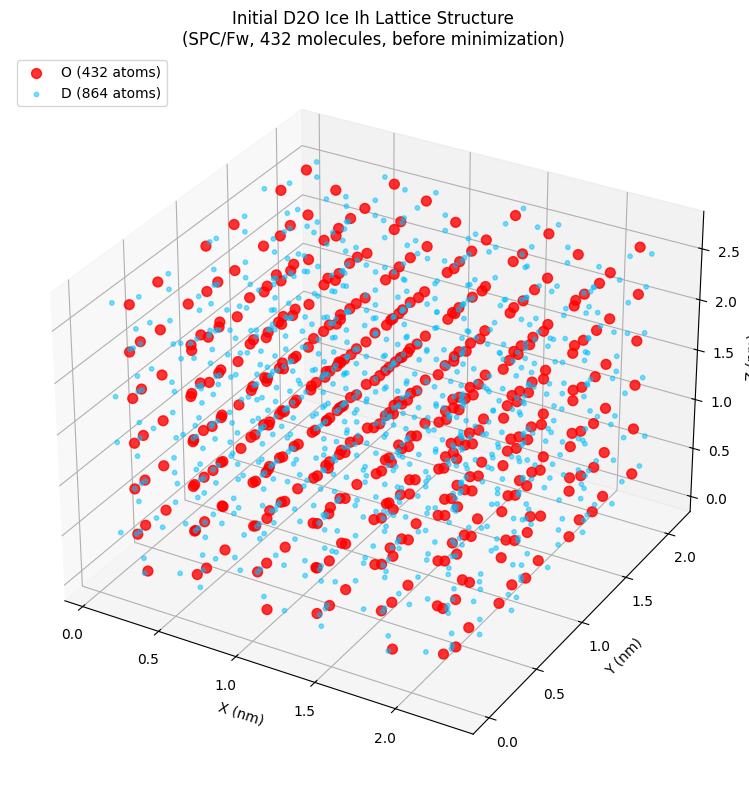

Initial lattice visualization saved: initial_lattice.png


In [9]:
def parse_gro_positions(gro_file):
    """Parse atom positions from a .gro file. Returns dict with 'O' and 'D' keys."""
    with open(gro_file, "r") as f:
        lines = f.readlines()

    n_atoms = int(lines[1].strip())
    positions = {"O": [], "D": []}

    for line in lines[2:2 + n_atoms]:
        atom_name = line[10:15].strip()
        x = float(line[20:28])
        y = float(line[28:36])
        z = float(line[36:44])

        if atom_name == "OW":
            positions["O"].append([x, y, z])
        elif atom_name in ("DW1", "DW2"):
            positions["D"].append([x, y, z])

    return {k: np.array(v) for k, v in positions.items() if len(v) > 0}


pos = parse_gro_positions("d2o_sim.gro")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

if "O" in pos:
    o_pos = pos["O"]
    ax.scatter(o_pos[:, 0], o_pos[:, 1], o_pos[:, 2],
               c='red', s=50, alpha=0.8, label=f'O ({len(o_pos)} atoms)')

if "D" in pos:
    d_pos = pos["D"]
    ax.scatter(d_pos[:, 0], d_pos[:, 1], d_pos[:, 2],
               c='deepskyblue', s=10, alpha=0.5, label=f'D ({len(d_pos)} atoms)')

ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
ax.set_zlabel('Z (nm)')
ax.set_title('Initial D2O Ice Ih Lattice Structure\n(SPC/Fw, 432 molecules, before minimization)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig("initial_lattice.png", dpi=150, bbox_inches='tight')
plt.show()
print("Initial lattice visualization saved: initial_lattice.png")

In [10]:
em_mdp = """\
; Energy minimization for D2O ice (SPC/Fw)
integrator  = steep
emtol       = 100.0
emstep      = 0.001
nsteps      = 5000

cutoff-scheme = Verlet
nstlist       = 10
pbc           = xyz

coulombtype   = PME
rcoulomb      = 1.0

vdwtype       = Cut-off
rvdw          = 1.0
DispCorr      = EnerPres

constraints   = none
"""

with open("em.mdp", "w") as f:
    f.write(em_mdp)
print("Written em.mdp")

result = subprocess.run(
    ["gmx", "grompp", "-f", "em.mdp", "-c", "d2o_sim.gro",
     "-p", "d2o_sim.top", "-o", "em.tpr", "-maxwarn", "5"],
    capture_output=True, text=True
)
print("=== grompp output ===")
print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])
else:
    print("grompp successful.")

Written em.mdp
=== grompp output ===
onded neighbours molecule type 'D2O_flex'
Analysing residue names:
There are:   432      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...

The largest distance between excluded atoms is 0.152 nm between atom 1004 and 1005
Calculating fourier grid dimensions for X Y Z
Using a fourier grid of 20x20x24, spacing 0.117 0.110 0.113

Estimate for the relative computational load of the PME mesh part: 0.20

This run will generate roughly 0 Mb of data

grompp successful.


In [11]:
result = subprocess.run(
    ["gmx", "mdrun", "-v", "-deffnm", "em"],
    capture_output=True, text=True
)
print(result.stdout[-1000:] if len(result.stdout) > 1000 else result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])
else:
    print("\nEnergy minimization complete.")



Energy minimization complete.


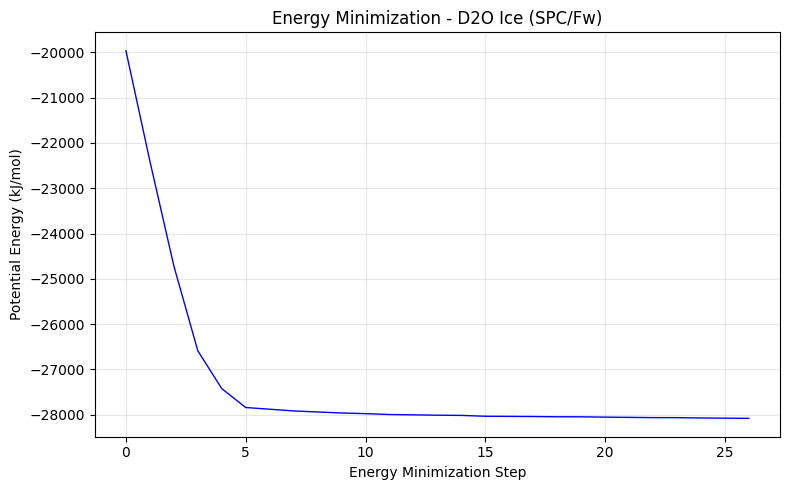

Final potential energy: -28079.2 kJ/mol


In [12]:
def parse_xvg(filename):
    """Parse a GROMACS .xvg file, skipping comment and header lines."""
    x, y = [], []
    with open(filename, "r") as f:
        for line in f:
            if line.startswith(("#", "@")):
                continue
            parts = line.split()
            if len(parts) >= 2:
                x.append(float(parts[0]))
                y.append(float(parts[1]))
    return np.array(x), np.array(y)


proc = subprocess.run(
    ["gmx", "energy", "-f", "em.edr", "-o", "em_potential.xvg"],
    input="Potential\n\n", capture_output=True, text=True
)

if os.path.exists("em_potential.xvg"):
    steps, energy = parse_xvg("em_potential.xvg")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(steps, energy, 'b-', linewidth=1)
    ax.set_xlabel("Energy Minimization Step")
    ax.set_ylabel("Potential Energy (kJ/mol)")
    ax.set_title("Energy Minimization - D2O Ice (SPC/Fw)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("em_energy.png", dpi=150)
    plt.show()
    print(f"Final potential energy: {energy[-1]:.1f} kJ/mol")

In [13]:
nvt_mdp = """\
; NVT equilibration for D2O ice at 94 K (SPC/Fw)
integrator  = md
dt          = 0.0005
nsteps      = 40000

nstxout     = 1000
nstvout     = 1000
nstenergy   = 100
nstlog      = 1000

cutoff-scheme = Verlet
nstlist       = 20
pbc           = xyz

coulombtype   = PME
rcoulomb      = 1.0

vdwtype       = Cut-off
rvdw          = 1.0
DispCorr      = EnerPres

tcoupl        = v-rescale
tc-grps       = System
tau-t         = 0.1
ref-t         = 94

pcoupl        = no

constraints   = none

gen-vel       = yes
gen-temp      = 94
gen-seed      = -1
"""

with open("nvt.mdp", "w") as f:
    f.write(nvt_mdp)
print("Written nvt.mdp")

result = subprocess.run(
    ["gmx", "grompp", "-f", "nvt.mdp", "-c", "em.gro",
     "-p", "d2o_sim.top", "-o", "nvt.tpr", "-maxwarn", "5"],
    capture_output=True, text=True
)
print(result.stdout[-300:])
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])
else:
    print("NVT grompp successful.")

Written nvt.mdp

Note that mdrun will redetermine rlist based on the actual pair-list setup
Calculating fourier grid dimensions for X Y Z
Using a fourier grid of 20x20x24, spacing 0.117 0.110 0.113

Estimate for the relative computational load of the PME mesh part: 0.22

This run will generate roughly 2 Mb of data

NVT grompp successful.


In [14]:
result = subprocess.run(
    ["gmx", "mdrun", "-v", "-deffnm", "nvt"],
    capture_output=True, text=True
)
print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
if result.returncode != 0:
    print("Error:", result.stderr[-300:])
else:
    print("\nNVT equilibration complete.")



NVT equilibration complete.


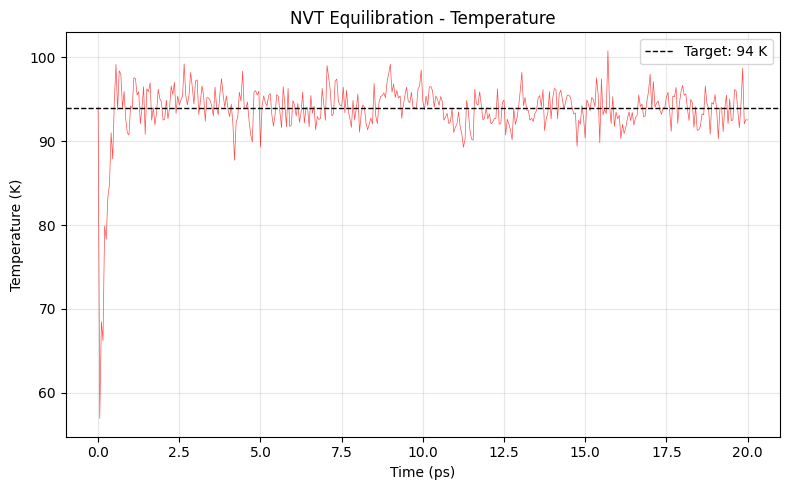

Average temperature (second half): 93.7 K


In [15]:
proc = subprocess.run(
    ["gmx", "energy", "-f", "nvt.edr", "-o", "nvt_temp.xvg"],
    input="Temperature\n\n", capture_output=True, text=True
)

if os.path.exists("nvt_temp.xvg"):
    time, temp = parse_xvg("nvt_temp.xvg")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(time, temp, 'r-', linewidth=0.5, alpha=0.7)
    ax.axhline(y=94, color='k', linestyle='--', linewidth=1, label='Target: 94 K')
    ax.set_xlabel("Time (ps)")
    ax.set_ylabel("Temperature (K)")
    ax.set_title("NVT Equilibration - Temperature")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("nvt_temperature.png", dpi=150)
    plt.show()
    print(f"Average temperature (second half): {np.mean(temp[len(temp)//2:]):.1f} K")

In [16]:
npt_mdp = """\
; NPT equilibration for D2O ice at 94 K, 1.5 bar (SPC/Fw)
integrator  = md
dt          = 0.0005
nsteps      = 40000

nstxout     = 1000
nstvout     = 1000
nstenergy   = 100
nstlog      = 1000

cutoff-scheme = Verlet
nstlist       = 20
pbc           = xyz

coulombtype   = PME
rcoulomb      = 1.0

vdwtype       = Cut-off
rvdw          = 1.0
DispCorr      = EnerPres

tcoupl        = v-rescale
tc-grps       = System
tau-t         = 0.1
ref-t         = 94

pcoupl        = Parrinello-Rahman
pcoupltype    = isotropic
tau-p         = 2.0
ref-p         = 1.5
compressibility = 4.5e-5

constraints   = none

gen-vel       = no
continuation  = yes
"""

with open("npt.mdp", "w") as f:
    f.write(npt_mdp)
print("Written npt.mdp")

result = subprocess.run(
    ["gmx", "grompp", "-f", "npt.mdp", "-c", "nvt.gro", "-t", "nvt.cpt",
     "-p", "d2o_sim.top", "-o", "npt.tpr", "-maxwarn", "5"],
    capture_output=True, text=True
)
print(result.stdout[-300:])
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])
else:
    print("NPT grompp successful.")

result = subprocess.run(
    ["gmx", "mdrun", "-v", "-deffnm", "npt"],
    capture_output=True, text=True
)
print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
if result.returncode != 0:
    print("Error:", result.stderr[-300:])
else:
    print("\nNPT equilibration complete.")

Written npt.mdp
d whole trajectory

Using frame at t = 20 ps

Starting time for run is 0 ps
Calculating fourier grid dimensions for X Y Z
Using a fourier grid of 20x20x24, spacing 0.117 0.110 0.113

Estimate for the relative computational load of the PME mesh part: 0.22

This run will generate roughly 2 Mb of data

NPT grompp successful.


NPT equilibration complete.


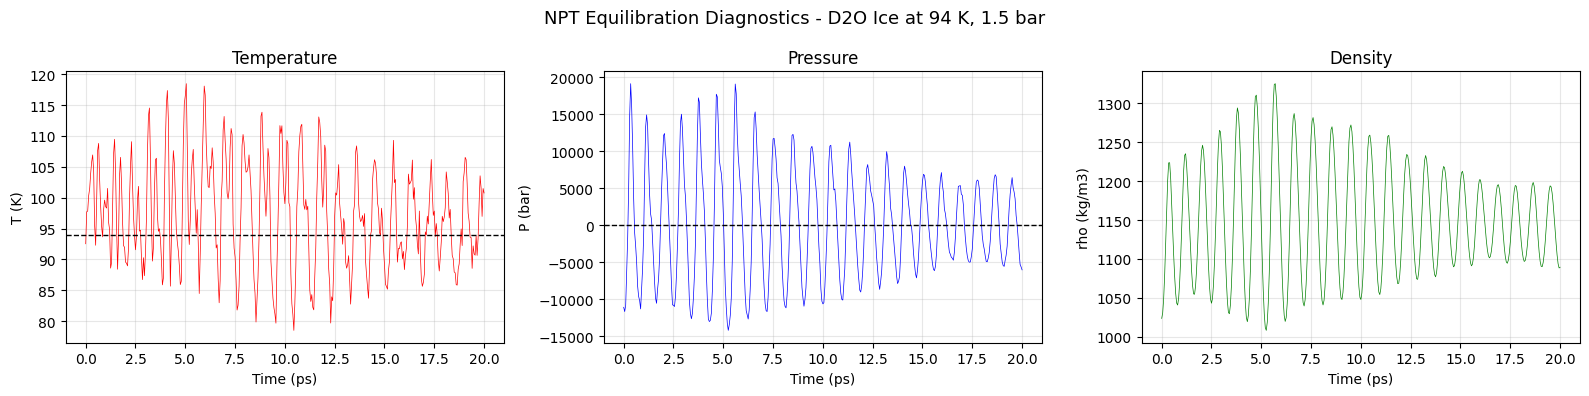

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

proc = subprocess.run(["gmx", "energy", "-f", "npt.edr", "-o", "npt_temp.xvg"],
                       input="Temperature\n\n", capture_output=True, text=True)
if os.path.exists("npt_temp.xvg"):
    t, temp = parse_xvg("npt_temp.xvg")
    axes[0].plot(t, temp, 'r-', lw=0.5)
    axes[0].axhline(94, color='k', ls='--', lw=1)
    axes[0].set_title("Temperature")
    axes[0].set_ylabel("T (K)")

proc = subprocess.run(["gmx", "energy", "-f", "npt.edr", "-o", "npt_press.xvg"],
                       input="Pressure\n\n", capture_output=True, text=True)
if os.path.exists("npt_press.xvg"):
    t, press = parse_xvg("npt_press.xvg")
    axes[1].plot(t, press, 'b-', lw=0.5)
    axes[1].axhline(1.5, color='k', ls='--', lw=1)
    axes[1].set_title("Pressure")
    axes[1].set_ylabel("P (bar)")

proc = subprocess.run(["gmx", "energy", "-f", "npt.edr", "-o", "npt_dens.xvg"],
                       input="Density\n\n", capture_output=True, text=True)
if os.path.exists("npt_dens.xvg"):
    t, dens = parse_xvg("npt_dens.xvg")
    axes[2].plot(t, dens, 'g-', lw=0.5)
    axes[2].set_title("Density")
    axes[2].set_ylabel("rho (kg/m3)")

for ax in axes:
    ax.set_xlabel("Time (ps)")
    ax.grid(True, alpha=0.3)

plt.suptitle("NPT Equilibration Diagnostics - D2O Ice at 94 K, 1.5 bar", fontsize=13)
plt.tight_layout()
plt.savefig("npt_diagnostics.png", dpi=150)
plt.show()

In [18]:
## Lattice Structure After Equilibration

#Compare the ice lattice before and after equilibration to confirm the
#crystal structure is maintained at 94 K.

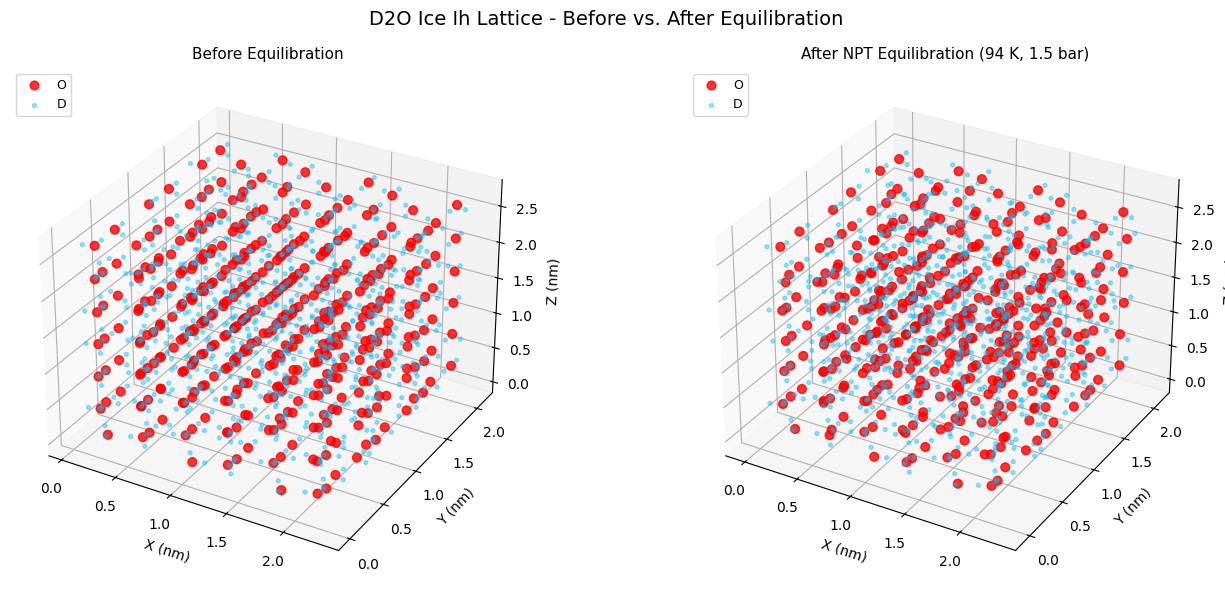

In [19]:
pos_before = parse_gro_positions("d2o_sim.gro")
pos_after = parse_gro_positions("npt.gro")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': '3d'})

for ax, pos, title in zip(axes, [pos_before, pos_after],
                            ["Before Equilibration", "After NPT Equilibration (94 K, 1.5 bar)"]):
    if "O" in pos:
        ax.scatter(pos["O"][:, 0], pos["O"][:, 1], pos["O"][:, 2],
                   c='red', s=40, alpha=0.8, label='O')
    if "D" in pos:
        ax.scatter(pos["D"][:, 0], pos["D"][:, 1], pos["D"][:, 2],
                   c='deepskyblue', s=8, alpha=0.4, label='D')
    ax.set_xlabel('X (nm)')
    ax.set_ylabel('Y (nm)')
    ax.set_zlabel('Z (nm)')
    ax.set_title(title, fontsize=11)
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle("D2O Ice Ih Lattice - Before vs. After Equilibration", fontsize=14)
plt.tight_layout()
plt.savefig("lattice_comparison.png", dpi=150)
plt.show()

In [20]:
prd_mdp = """\
; NVE Production for VDOS - D2O ice (SPC/Fw)
integrator  = md
dt          = 0.0005
nsteps      = 40000

nstxout     = 0
nstvout     = 1
nstfout     = 0
nstenergy   = 100
nstlog      = 1000
nstxout-compressed = 1000

cutoff-scheme = Verlet
nstlist       = 20
pbc           = xyz

coulombtype   = PME
rcoulomb      = 1.0

vdwtype       = Cut-off
rvdw          = 1.0
DispCorr      = EnerPres

tcoupl        = no
pcoupl        = no

constraints   = none

gen-vel       = no
continuation  = yes
"""

with open("prd.mdp", "w") as f:
    f.write(prd_mdp)
print("Written prd.mdp")

result = subprocess.run(
    ["gmx", "grompp", "-f", "prd.mdp", "-c", "npt.gro", "-t", "npt.cpt",
     "-p", "d2o_sim.top", "-o", "prd.tpr", "-maxwarn", "5"],
    capture_output=True, text=True
)
print(result.stdout[-300:])
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])
else:
    print("Production grompp successful.")

Written prd.mdp
whole trajectory

Using frame at t = 20 ps

Starting time for run is 0 ps
Calculating fourier grid dimensions for X Y Z
Using a fourier grid of 20x20x24, spacing 0.115 0.108 0.111

Estimate for the relative computational load of the PME mesh part: 0.21

This run will generate roughly 594 Mb of data

Production grompp successful.


In [21]:
print("Starting NVE production run (20 ps, velocities every 0.5 fs)...")
print("This will take a while on a MacBook Air. Be patient.\n")

result = subprocess.run(
    ["gmx", "mdrun", "-v", "-deffnm", "prd"],
    capture_output=True, text=True
)

output = result.stdout + result.stderr
print(output[-1000:] if len(output) > 1000 else output)

if result.returncode == 0:
    print("\nProduction run complete.")
else:
    print("\nProduction run failed. Check the output above.")

for f in ["prd.trr", "prd.edr", "prd.xtc"]:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / (1024**2)
        print(f"  {f}: {size_mb:.1f} MB")

Starting NVE production run (20 ps, velocities every 0.5 fs)...
This will take a while on a MacBook Air. Be patient.

, remaining wall clock time:     1 s          
step 39100, remaining wall clock time:     1 s          
step 39200, remaining wall clock time:     1 s          
step 39300, remaining wall clock time:     1 s          
step 39400, remaining wall clock time:     0 s          
step 39500, remaining wall clock time:     0 s          
step 39600, remaining wall clock time:     0 s          
step 39700, remaining wall clock time:     0 s          
step 39800, remaining wall clock time:     0 s          
step 39900, remaining wall clock time:     0 s          
Writing final coordinates.

step 40000, remaining wall clock time:     0 s          
               Core t (s)   Wall t (s)        (%)
       Time:      493.558       61.695      800.0
                 (ns/day)    (hour/ns)
Performance:       28.010        0.857

GROMACS reminds you: "I don't know how many of you have ev

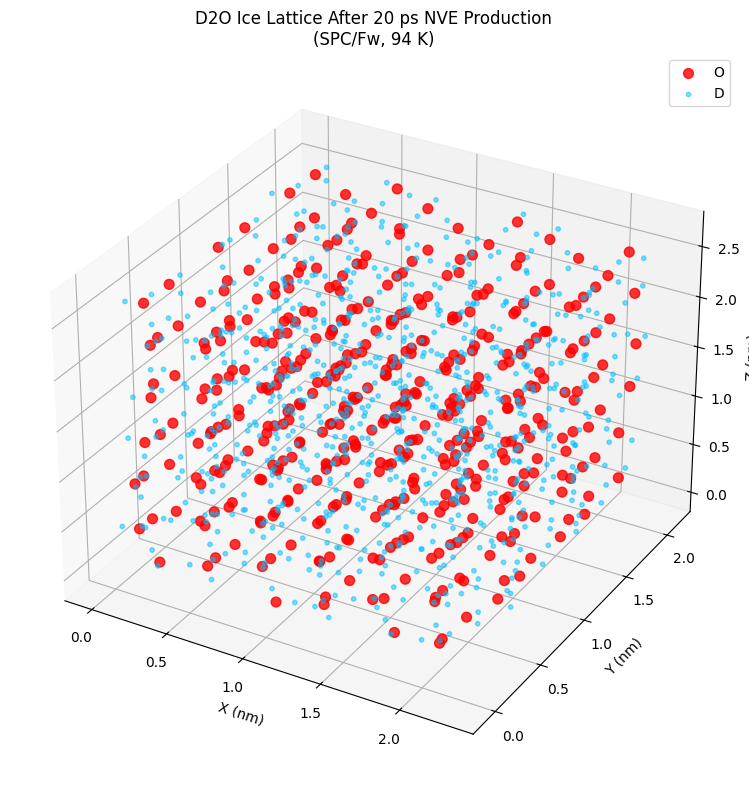

Post-production lattice visualization saved.


In [22]:
pos_final = parse_gro_positions("prd.gro")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

if "O" in pos_final:
    ax.scatter(pos_final["O"][:, 0], pos_final["O"][:, 1], pos_final["O"][:, 2],
               c='red', s=50, alpha=0.8, label='O')
if "D" in pos_final:
    ax.scatter(pos_final["D"][:, 0], pos_final["D"][:, 1], pos_final["D"][:, 2],
               c='deepskyblue', s=10, alpha=0.5, label='D')

ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
ax.set_zlabel('Z (nm)')
ax.set_title('D2O Ice Lattice After 20 ps NVE Production\n(SPC/Fw, 94 K)')
ax.legend()
plt.tight_layout()
plt.savefig("post_production_lattice.png", dpi=150)
plt.show()
print("Post-production lattice visualization saved.")

In [24]:
# Generate a default index file so gmx velacc can find group definitions
result = subprocess.run(
    ["gmx", "make_ndx", "-f", "prd.tpr", "-o", "index.ndx"],
    input="q\n",
    capture_output=True, text=True
)

print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])
else:
    print("Index file generated: index.ndx")

System              :  1296 atoms
  1 Other               :  1296 atoms
  2 ICE                 :  1296 atoms

 nr : group      '!': not  'name' nr name   'splitch' nr    Enter: list groups
 'a': atom       '&': and  'del' nr         'splitres' nr   'l': list residues
 't': atom type  '|': or   'keep' nr        'splitat' nr    'h': help
 'r': residue              'res' nr         'chain' char
 "name": group             'case': case sensitive           'q': save and quit
 'ri': residue index

> 

Index file generated: index.ndx


In [25]:
print("Computing velocity autocorrelation function and VDOS...")
print("This reads all 40,000 velocity frames and may take a minute.\n")

result = subprocess.run(
    ["gmx", "velacc",
     "-f", "prd.trr",
     "-s", "prd.tpr",
     "-n", "index.ndx",
     "-o", "vacf.xvg",
     "-os", "vdos.xvg",
     "-recip",
     "-normalize",
     "-acflen", "0",
     "-xvg", "none"],
    input="0\n",
    capture_output=True, text=True
)

print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-500:])
else:
    print("VDOS calculation complete.")
    for f in ["vacf.xvg", "vdos.xvg"]:
        if os.path.exists(f):
            print(f"  {f} exists.")

Computing velocity autocorrelation function and VDOS...
This reads all 40,000 velocity frames and may take a minute.

Selected 0: 'System'

VDOS calculation complete.
  vacf.xvg exists.
  vdos.xvg exists.


In [30]:
# The VACF file (vacf.xvg) came out empty, but the power spectrum (vdos.xvg)
# was computed correctly. This happens with some versions of gmx velacc when
# using -xvg none. The VDOS is what we need, so we proceed directly to plotting.

def parse_xvg_fixed(filename):
    """Parse a GROMACS .xvg file, handling leading whitespace and various formats."""
    x, y = [], []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(("#", "@", "&")):
                continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    x.append(float(parts[0]))
                    y.append(float(parts[1]))
                except ValueError:
                    continue
    return np.array(x), np.array(y)

# Verify it works
wn_test, int_test = parse_xvg_fixed("vdos.xvg")
print(f"VDOS data: {len(wn_test)} points")
print(f"Wavenumber range: {wn_test[0]:.1f} to {wn_test[-1]:.1f} cm-1")
print(f"Max intensity at: {wn_test[np.argmax(int_test)]:.1f} cm-1")

VDOS data: 10000 points
Wavenumber range: 0.0 to 33353.1 cm-1
Max intensity at: 23.3 cm-1


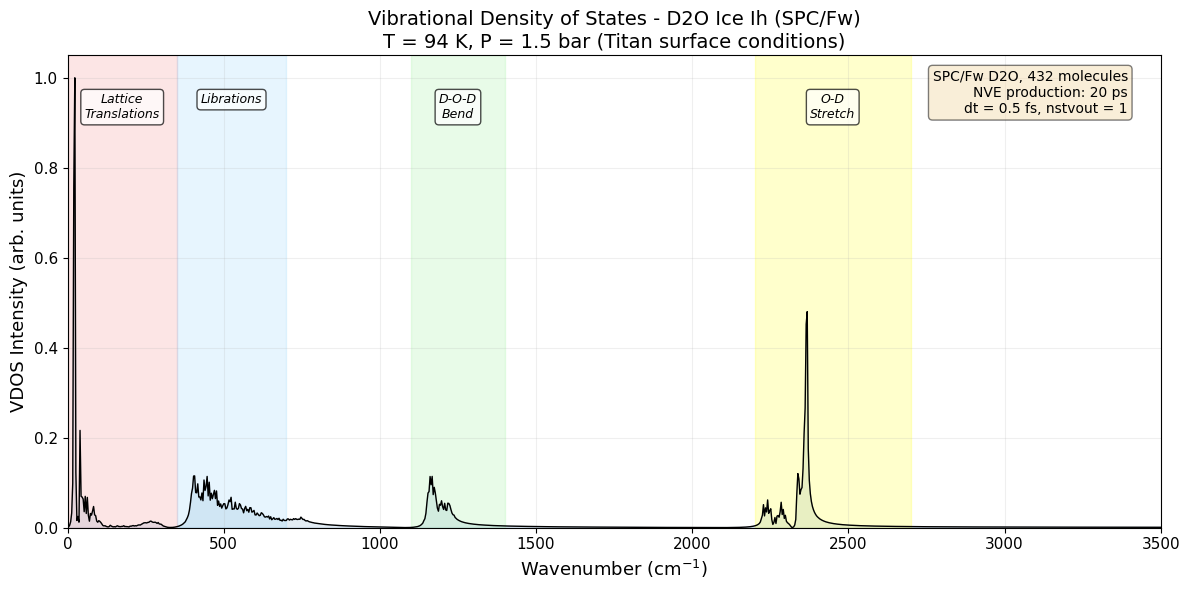

VDOS plot saved as d2o_ice_vdos.png and d2o_ice_vdos.pdf


In [34]:
wavenumber, intensity = parse_xvg_fixed("vdos.xvg")

mask = (wavenumber >= 0) & (wavenumber <= 4000)
wn = wavenumber[mask]
inten = intensity[mask]
inten = inten / np.max(inten)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(wn, inten, 'k-', linewidth=1.0)
ax.fill_between(wn, inten, alpha=0.15, color='steelblue')

bands = [
    (0, 350, "Lattice\nTranslations", 'lightcoral'),
    (350, 700, "Librations", 'lightskyblue'),
    (1100, 1400, "D-O-D\nBend", 'lightgreen'),
    (2200, 2700, "O-D\nStretch", 'yellow'),
]

for lo, hi, label, color in bands:
    ax.axvspan(lo, hi, alpha=0.2, color=color)
    mid = (lo + hi) / 2
    ax.text(mid, 0.92, label,
            ha='center', va='top', fontsize=9, fontstyle='italic',
            transform=ax.get_xaxis_transform(),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_xlabel("Wavenumber (cm$^{-1}$)", fontsize=13)
ax.set_ylabel("VDOS Intensity (arb. units)", fontsize=13)
ax.set_title("Vibrational Density of States - D2O Ice Ih (SPC/Fw)\n"
             "T = 94 K, P = 1.5 bar (Titan surface conditions)", fontsize=14)
ax.set_xlim(0, 3500)
ax.set_ylim(bottom=0)
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.2)

textstr = (f"SPC/Fw D2O, {n_mol} molecules\n"
           f"NVE production: 20 ps\n"
           f"dt = 0.5 fs, nstvout = 1")
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.97, 0.97, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig("d2o_ice_vdos.png", dpi=300, bbox_inches='tight')
plt.savefig("d2o_ice_vdos.pdf", bbox_inches='tight')
plt.show()

print("VDOS plot saved as d2o_ice_vdos.png and d2o_ice_vdos.pdf")

Oxygen atoms: 432
Deuterium atoms: 864
O-D bonds found: 864


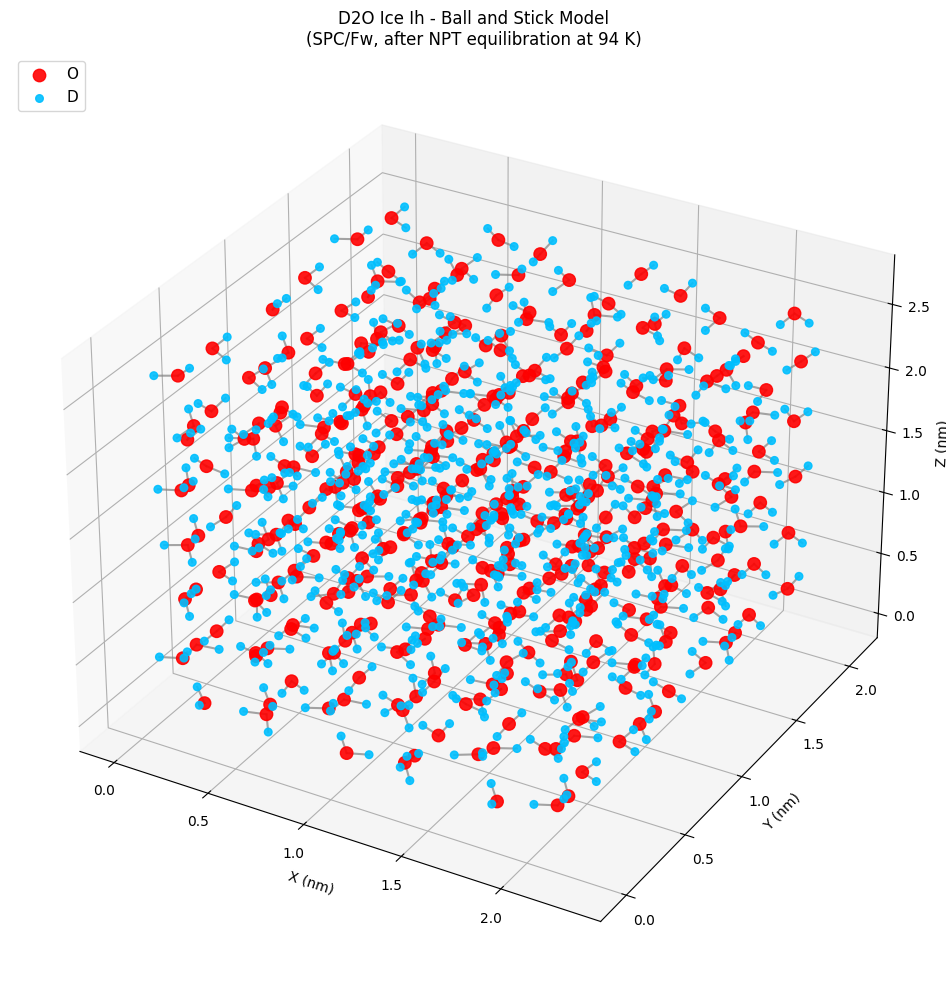

Saved: ball_and_stick_lattice.png


In [36]:
import mdtraj as md

# Load the post-equilibration structure
traj = md.load("npt.gro")
topology = traj.topology

# Get atom positions in Angstroms (mdtraj uses nm, we convert for display)
positions = traj.xyz[0]  # nm

# Separate O and D positions and indices
o_indices = [a.index for a in topology.atoms if a.name == "OW"]
d_indices = [a.index for a in topology.atoms if a.name in ("DW1", "DW2")]

o_pos = positions[o_indices]
d_pos = positions[d_indices]

# Build bond list: connect each D to its nearest O (within 0.12 nm = 1.2 A)
bonds = []
for i, di in enumerate(d_indices):
    d_xyz = positions[di]
    min_dist = 999.0
    nearest_o = None
    for j, oi in enumerate(o_indices):
        o_xyz = positions[oi]
        # Minimum image distance (simple, works for orthorhombic box)
        delta = d_xyz - o_xyz
        box = traj.unitcell_lengths[0]
        delta -= box * np.round(delta / box)
        dist = np.linalg.norm(delta)
        if dist < min_dist:
            min_dist = dist
            nearest_o = oi
            nearest_o_xyz = o_xyz + box * np.round((d_xyz - o_xyz) / box) - (d_xyz - o_xyz - delta)
    if min_dist < 0.12:  # O-D bond cutoff in nm
        bonds.append((di, nearest_o))

print(f"Oxygen atoms: {len(o_indices)}")
print(f"Deuterium atoms: {len(d_indices)}")
print(f"O-D bonds found: {len(bonds)}")

# Plot ball-and-stick
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot oxygens (red spheres)
ax.scatter(o_pos[:, 0], o_pos[:, 1], o_pos[:, 2],
           c='red', s=80, alpha=0.9, label='O', depthshade=True)

# Plot deuteriums (light blue, smaller)
ax.scatter(d_pos[:, 0], d_pos[:, 1], d_pos[:, 2],
           c='deepskyblue', s=30, alpha=0.9, label='D', depthshade=True)

# Draw bonds
box = traj.unitcell_lengths[0]
for di, oi in bonds:
    p1 = positions[di]
    p2 = positions[oi]
    delta = p1 - p2
    delta -= box * np.round(delta / box)
    # Only draw if bond doesn't cross periodic boundary (for visual clarity)
    if np.all(np.abs(delta) < 0.12):
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                'gray', linewidth=1.5, alpha=0.7)

ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
ax.set_zlabel('Z (nm)')
ax.set_title('D2O Ice Ih - Ball and Stick Model\n(SPC/Fw, after NPT equilibration at 94 K)')
ax.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig("ball_and_stick_lattice.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved: ball_and_stick_lattice.png")

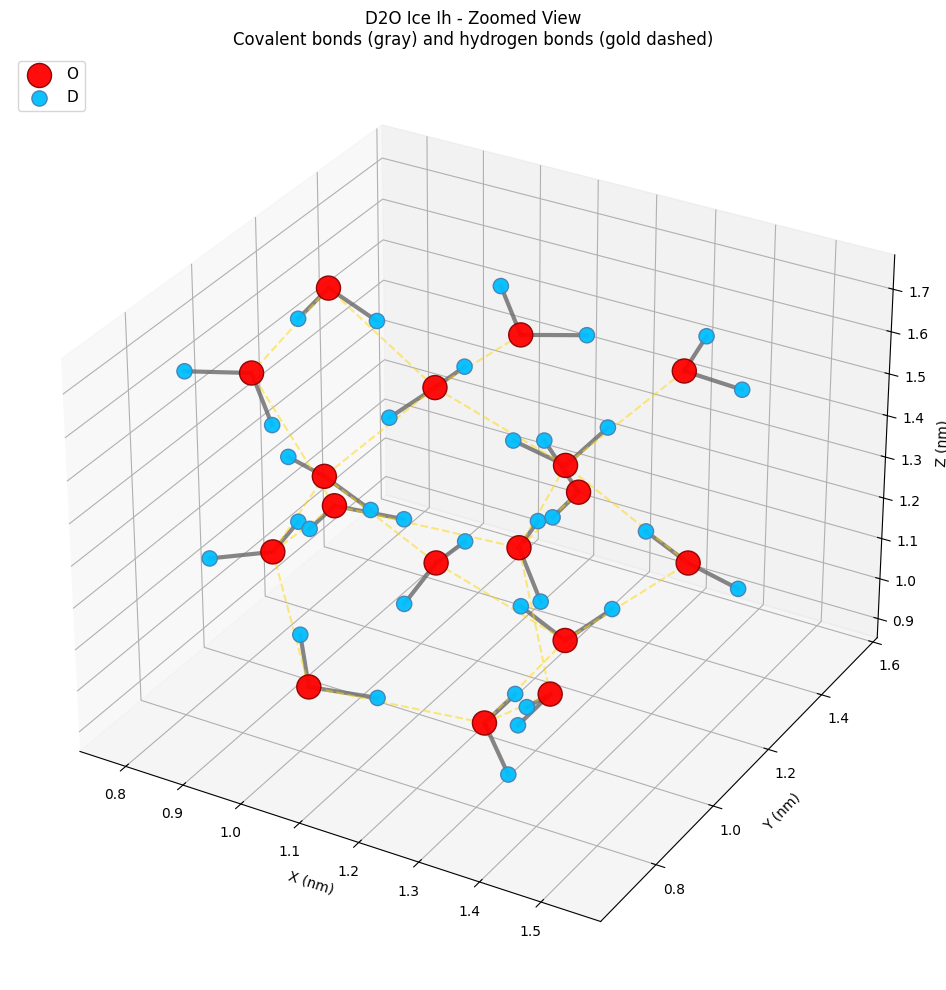

Saved: ball_and_stick_zoom.png


In [38]:
# Zoom into a small region to see individual molecules clearly
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Pick a center point and show molecules within 0.5 nm
center = np.mean(o_pos, axis=0)
radius = 0.5  # nm

# Find oxygens near center
nearby_o = []
for i, oi in enumerate(o_indices):
    delta = positions[oi] - center
    box = traj.unitcell_lengths[0]
    delta -= box * np.round(delta / box)
    if np.linalg.norm(delta) < radius:
        nearby_o.append(oi)

# Find deuteriums bonded to nearby oxygens
nearby_d = []
for di, oi in bonds:
    if oi in nearby_o:
        nearby_d.append(di)

nearby_o_pos = positions[nearby_o]
nearby_d_pos = positions[nearby_d]

# Plot with larger markers
ax.scatter(nearby_o_pos[:, 0], nearby_o_pos[:, 1], nearby_o_pos[:, 2],
           c='red', s=300, alpha=0.95, label='O', depthshade=True, edgecolors='darkred')
ax.scatter(nearby_d_pos[:, 0], nearby_d_pos[:, 1], nearby_d_pos[:, 2],
           c='deepskyblue', s=120, alpha=0.95, label='D', depthshade=True, edgecolors='steelblue')

# Draw bonds for nearby molecules
for di, oi in bonds:
    if oi in nearby_o:
        p1 = positions[di]
        p2 = positions[oi]
        delta = p1 - p2
        delta -= box * np.round(delta / box)
        if np.all(np.abs(delta) < 0.12):
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                    'dimgray', linewidth=3, alpha=0.8)

# Draw hydrogen bonds (O...O distances between 0.25-0.35 nm)
for i, oi1 in enumerate(nearby_o):
    for j, oi2 in enumerate(nearby_o):
        if oi1 >= oi2:
            continue
        p1 = positions[oi1]
        p2 = positions[oi2]
        delta = p1 - p2
        delta -= box * np.round(delta / box)
        dist = np.linalg.norm(delta)
        if 0.25 < dist < 0.35:
            p2_img = p1 - delta
            ax.plot([p1[0], p2_img[0]], [p1[1], p2_img[1]], [p1[2], p2_img[2]],
                    'gold', linewidth=1.5, alpha=0.5, linestyle='--')

ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
ax.set_zlabel('Z (nm)')
ax.set_title('D2O Ice Ih - Zoomed View\nCovalent bonds (gray) and hydrogen bonds (gold dashed)')
ax.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig("ball_and_stick_zoom.png", dpi=200, bbox_inches='tight')
plt.show()
print("Saved: ball_and_stick_zoom.png")

In [39]:
from PIL import Image
import io

# Load production trajectory (use the compressed.xtc for coordinates)
# We saved coordinates every 1000 steps = every 0.5 ps in the.xtc
traj_prd = md.load("prd.xtc", top="prd.gro")
print(f"Production trajectory: {traj_prd.n_frames} frames, {traj_prd.n_atoms} atoms")

# For the animation, zoom into the same region as above
# Use every frame from the.xtc (should be ~40 frames at nstxout-compressed=1000)
center = np.mean(traj_prd.xyz[0][o_indices], axis=0)
box0 = traj_prd.unitcell_lengths[0]
radius = 0.5

# Identify nearby molecules from first frame
nearby_o_anim = []
for oi in o_indices:
    delta = traj_prd.xyz[0][oi] - center
    delta -= box0 * np.round(delta / box0)
    if np.linalg.norm(delta) < radius:
        nearby_o_anim.append(oi)

nearby_d_anim = []
for di, oi in bonds:
    if oi in nearby_o_anim:
        nearby_d_anim.append(di)

all_nearby = nearby_o_anim + nearby_d_anim

print(f"Animating {len(nearby_o_anim)} O atoms and {len(nearby_d_anim)} D atoms")
print(f"Rendering {traj_prd.n_frames} frames...")

# Render each frame
frames = []
for frame_idx in range(traj_prd.n_frames):
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    pos_frame = traj_prd.xyz[frame_idx]
    box_frame = traj_prd.unitcell_lengths[frame_idx]
    
    o_pos_f = pos_frame[nearby_o_anim]
    d_pos_f = pos_frame[nearby_d_anim]
    
    ax.scatter(o_pos_f[:, 0], o_pos_f[:, 1], o_pos_f[:, 2],
               c='red', s=250, alpha=0.95, depthshade=True, edgecolors='darkred')
    ax.scatter(d_pos_f[:, 0], d_pos_f[:, 1], d_pos_f[:, 2],
               c='deepskyblue', s=100, alpha=0.95, depthshade=True, edgecolors='steelblue')
    
    # Draw covalent bonds
    for di, oi in bonds:
        if oi in nearby_o_anim:
            p1 = pos_frame[di]
            p2 = pos_frame[oi]
            delta = p1 - p2
            delta -= box_frame * np.round(delta / box_frame)
            if np.all(np.abs(delta) < 0.15):
                ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                        'dimgray', linewidth=2.5, alpha=0.8)
    
    # Draw hydrogen bonds
    for i, oi1 in enumerate(nearby_o_anim):
        for j, oi2 in enumerate(nearby_o_anim):
            if oi1 >= oi2:
                continue
            p1 = pos_frame[oi1]
            p2 = pos_frame[oi2]
            delta = p1 - p2
            delta -= box_frame * np.round(delta / box_frame)
            dist = np.linalg.norm(delta)
            if 0.25 < dist < 0.35:
                p2_img = p1 - delta
                ax.plot([p1[0], p2_img[0]], [p1[1], p2_img[1]], [p1[2], p2_img[2]],
                        'gold', linewidth=1.5, alpha=0.4, linestyle='--')
    
    # Fix the view limits to prevent jitter
    all_pos = np.vstack([o_pos_f, d_pos_f])
    mid = np.mean(all_pos, axis=0)
    span = 0.55
    ax.set_xlim(mid[0] - span, mid[0] + span)
    ax.set_ylim(mid[1] - span, mid[1] + span)
    ax.set_zlim(mid[2] - span, mid[2] + span)
    
    time_ps = traj_prd.time[frame_idx] / 1000.0 if traj_prd.time[frame_idx] > 100 else traj_prd.time[frame_idx]
    ax.set_title(f'D2O Ice Vibrations (SPC/Fw, 94 K)\nt = {traj_prd.time[frame_idx]:.2f} ps', fontsize=12)
    ax.set_xlabel('X (nm)')
    ax.set_ylabel('Y (nm)')
    ax.set_zlabel('Z (nm)')
    
    # Render to image buffer
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    buf.close()
    plt.close(fig)
    
    if (frame_idx + 1) % 10 == 0:
        print(f"  Rendered frame {frame_idx + 1}/{traj_prd.n_frames}")

print(f"All {len(frames)} frames rendered.")

# Save as GIF
frames[0].save(
    "d2o_ice_vibrations.gif",
    save_all=True,
    append_images=frames[1:],
    duration=150,  # ms per frame
    loop=0
)

file_size = os.path.getsize("d2o_ice_vibrations.gif") / (1024**2)
print(f"Animation saved: d2o_ice_vibrations.gif ({file_size:.1f} MB)")

Production trajectory: 41 frames, 1296 atoms
Animating 17 O atoms and 34 D atoms
Rendering 41 frames...
  Rendered frame 10/41
  Rendered frame 20/41
  Rendered frame 30/41
  Rendered frame 40/41
All 41 frames rendered.
Animation saved: d2o_ice_vibrations.gif (1.1 MB)


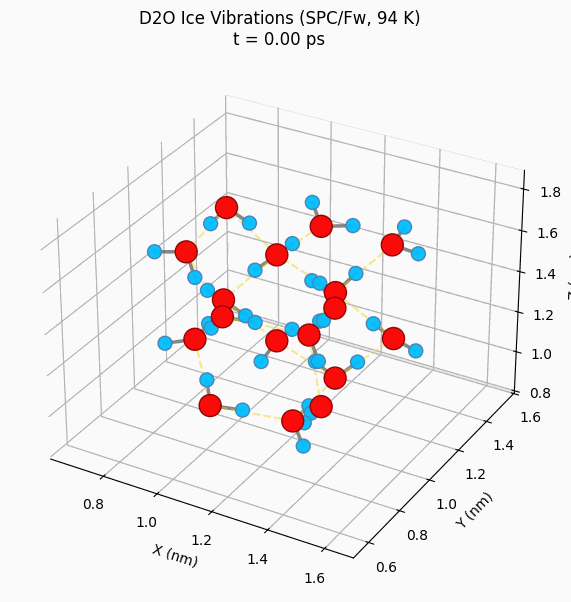

In [40]:
from IPython.display import Image as IPImage, display

display(IPImage(filename="d2o_ice_vibrations.gif"))